=== Running GA-Otsu Hybrid ===


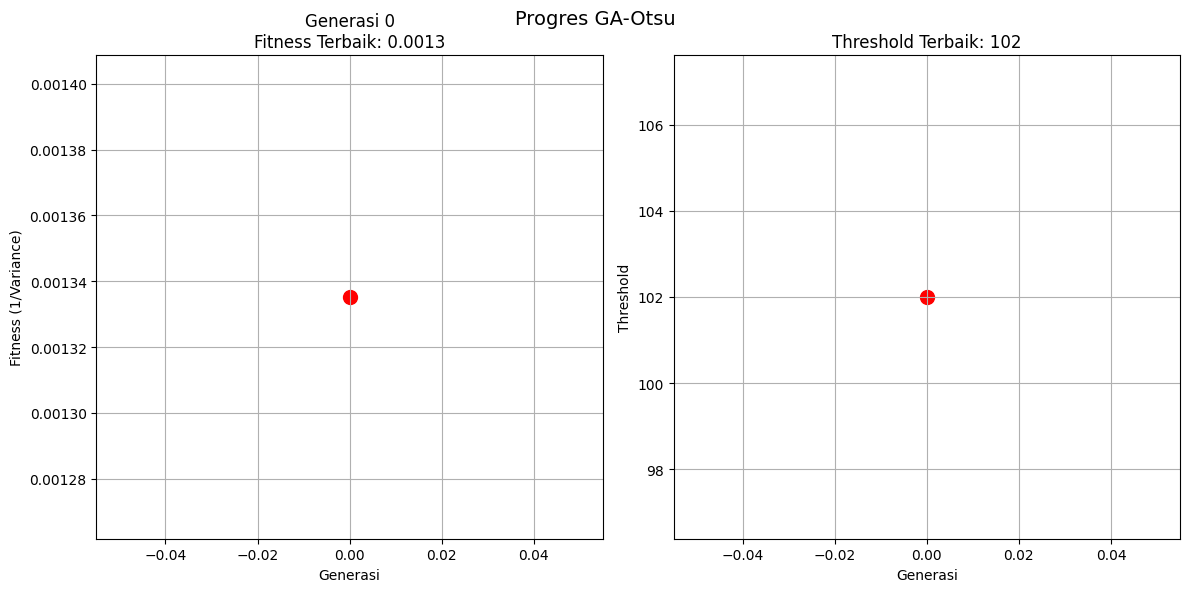

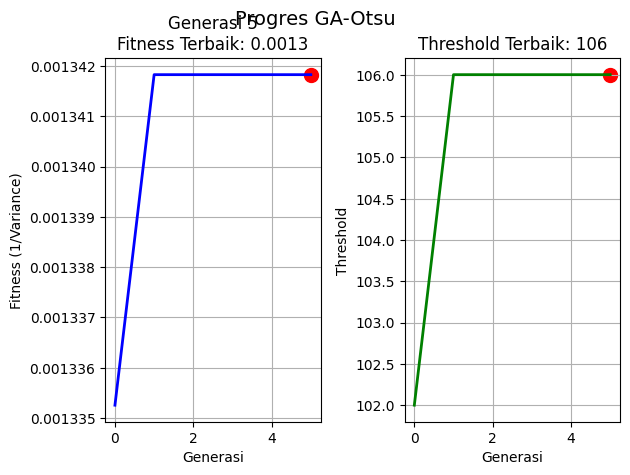

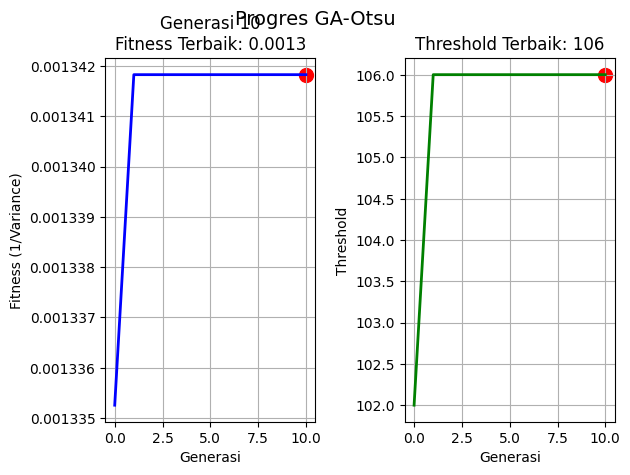

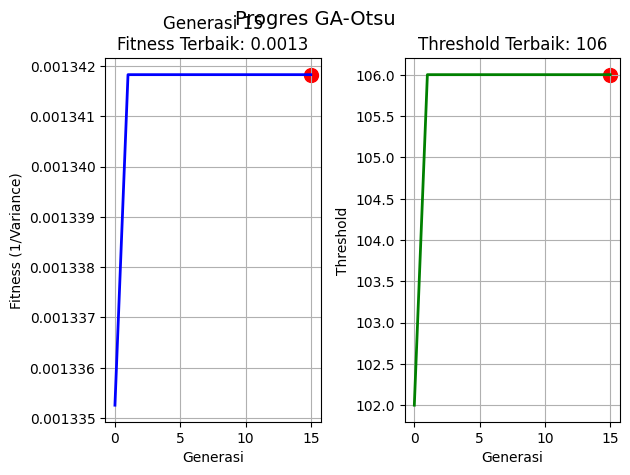

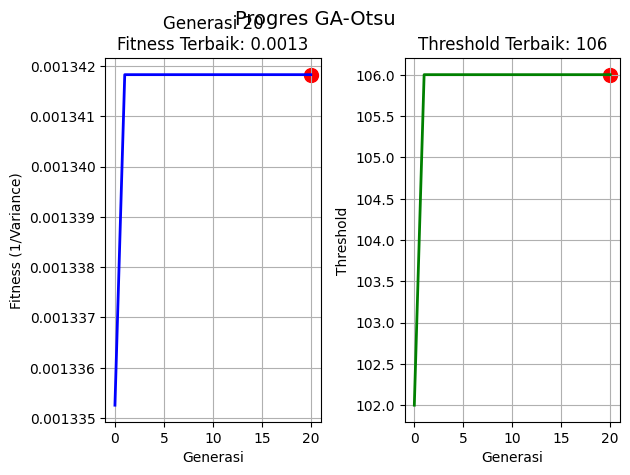

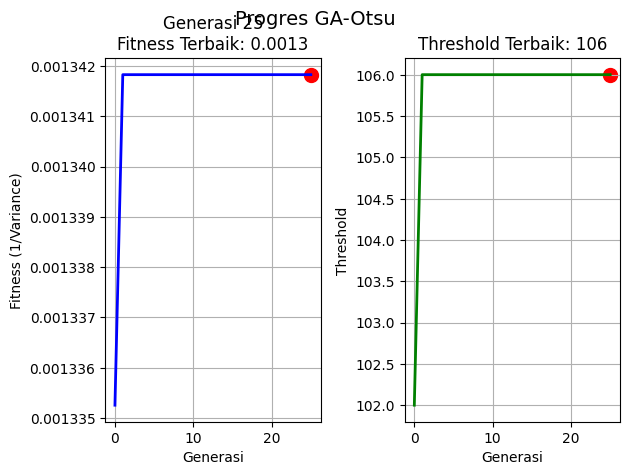

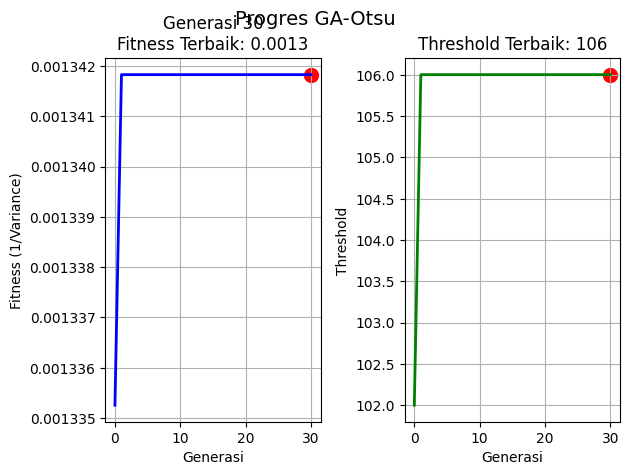

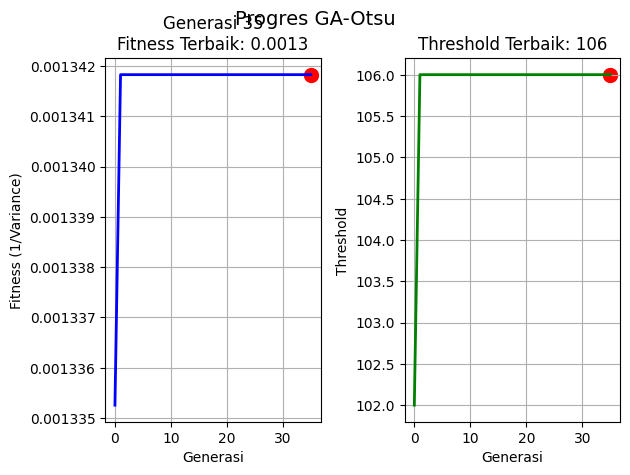

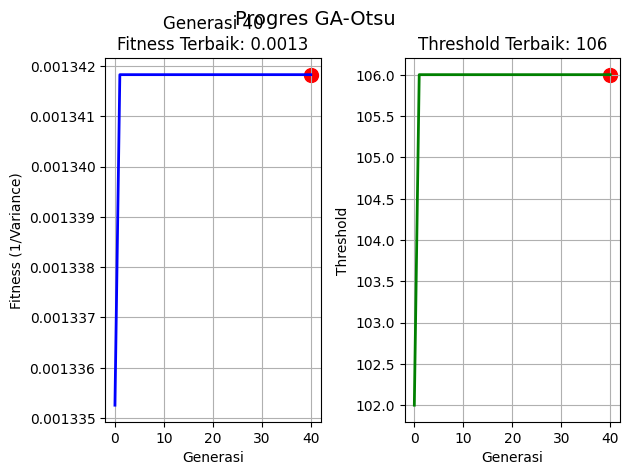

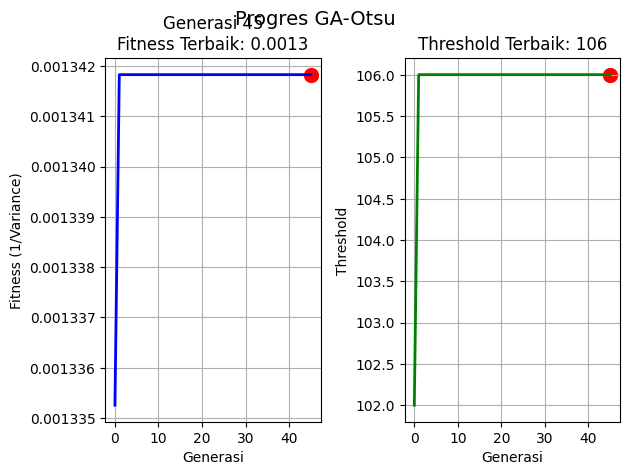

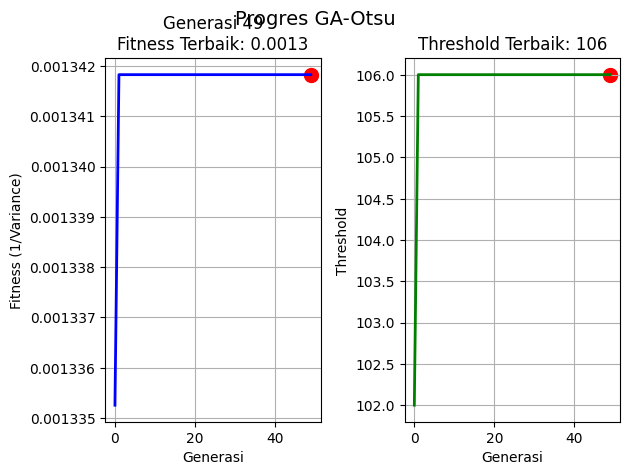

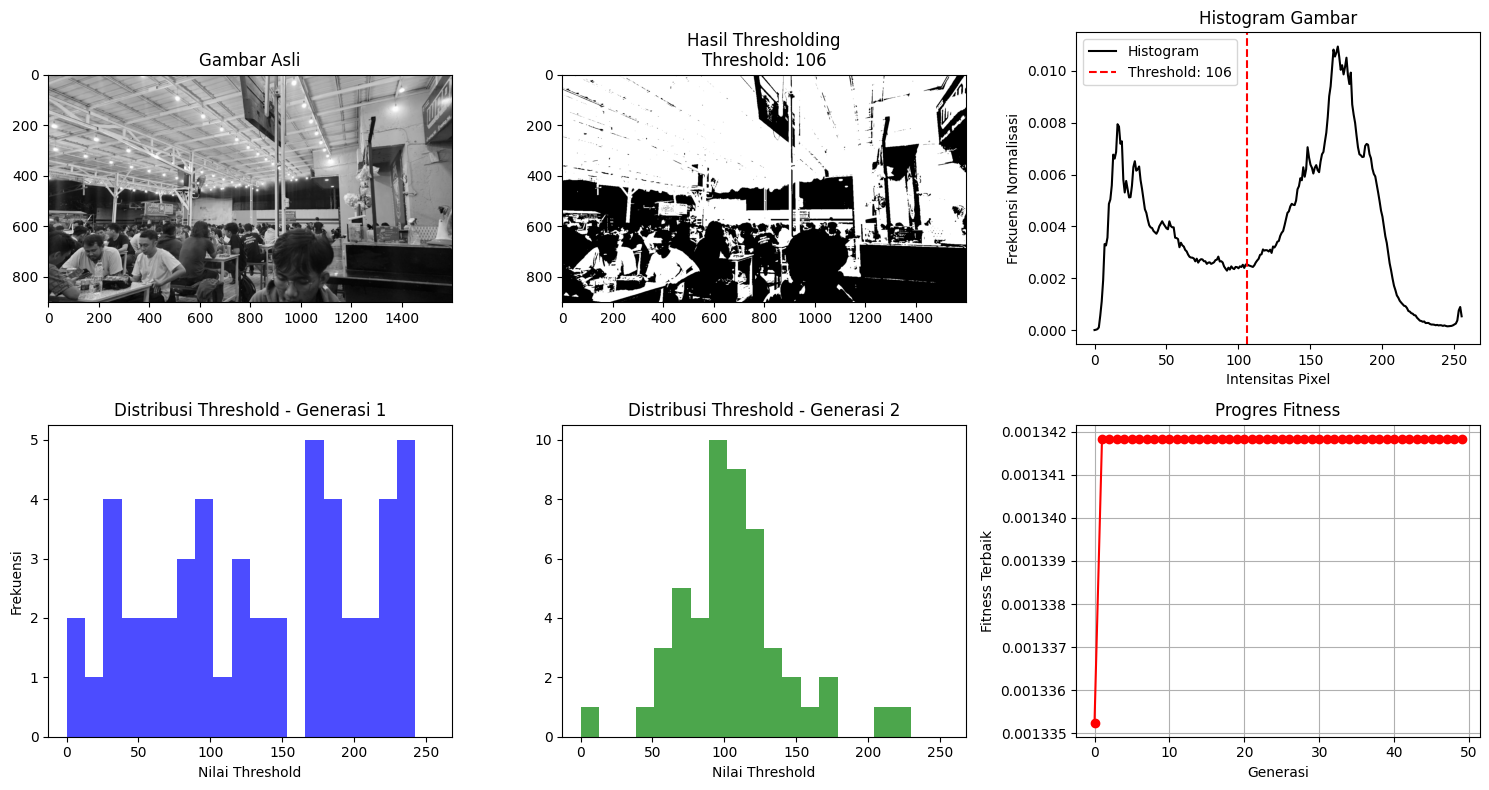

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Hitung Histogram (Normalized)
def calculate_histogram(image):
    hist = np.zeros(256)
    for pixel in image.flatten():
        hist[pixel] += 1
    return hist / image.size  # Normalisasi

# 2. Kelas GA-Otsu Hybrid
class GA_Otsu:
    def __init__(self, image, pop_size=50, generations=100):
        self.image = image
        self.hist = calculate_histogram(image)
        self.pop_size = pop_size
        self.generations = generations
        self.fitness_history = []
        self.threshold_history = []
        self.population_history = []  # Menyimpan seluruh populasi per generasi

    def fitness(self, th):
        """Fungsi fitness berdasarkan inverse within-class variance Otsu"""
        w0 = np.sum(self.hist[:th])
        w1 = np.sum(self.hist[th:])
        if w0 == 0 or w1 == 0:
            return 0  # Hindari pembagian nol

        mean0 = np.sum(np.arange(th) * self.hist[:th]) / w0
        mean1 = np.sum(np.arange(th, 256) * self.hist[th:]) / w1

        var0 = np.sum((np.arange(th) - mean0)**2 * self.hist[:th]) / w0
        var1 = np.sum((np.arange(th, 256) - mean1)**2 * self.hist[th:]) / w1

        return 1 / (w0 * var0 + w1 * var1 + 1e-10)  # Fitness = 1/variance

    def run(self):
        """Algoritma Genetika Utama"""
        population = np.random.randint(0, 256, self.pop_size)

        plt.figure(figsize=(12, 6))
        plt.ion()  # Aktifkan mode interaktif

        for gen in range(self.generations):
            # Hitung fitness
            fitness_values = np.array([self.fitness(th) for th in population])
            best_idx = np.argmax(fitness_values)
            best_th = population[best_idx]
            best_fitness = fitness_values[best_idx]

            # Simpan progres
            self.fitness_history.append(best_fitness)
            self.threshold_history.append(best_th)
            self.population_history.append(population.copy())  # Simpan populasi

            # Update plot setiap 5 generasi
            if gen % 5 == 0 or gen == self.generations - 1:
                self._plot_progress(gen)
                plt.pause(0.1)  # Jeda singkat untuk animasi

            # Seleksi Orang Tua (Tournament Selection)
            parents = []
            for _ in range(self.pop_size):
                candidates = np.random.choice(len(population), size=3, replace=False)
                winner = candidates[np.argmax(fitness_values[candidates])]
                parents.append(population[winner])

            # Crossover (Aritmetik)
            offspring = []
            for i in range(0, len(parents), 2):
                child1 = (parents[i] + parents[i+1]) // 2
                child2 = parents[i] if np.random.rand() > 0.5 else parents[i+1]
                offspring.extend([child1, child2])

            # Mutasi
            for i in range(len(offspring)):
                if np.random.rand() < 0.1:  # Probabilitas mutasi 10%
                    offspring[i] = np.clip(offspring[i] + np.random.randint(-10, 11), 0, 255)

            # Elitism: Pertahankan individu terbaik
            offspring[0] = best_th
            population = np.array(offspring)

        plt.ioff()  # Nonaktifkan mode interaktif
        return best_th

    def _plot_progress(self, gen):
        """Visualisasi real-time progres GA"""
        plt.clf()

        # Plot Fitness
        plt.subplot(1, 2, 1)
        plt.plot(self.fitness_history, 'b-', linewidth=2)
        plt.scatter(len(self.fitness_history)-1, self.fitness_history[-1], c='red', s=100)
        plt.xlabel("Generasi")
        plt.ylabel("Fitness (1/Variance)")
        plt.title(f"Generasi {gen}\nFitness Terbaik: {self.fitness_history[-1]:.4f}")
        plt.grid(True)

        # Plot Threshold
        plt.subplot(1, 2, 2)
        plt.plot(self.threshold_history, 'g-', linewidth=2)
        plt.scatter(len(self.threshold_history)-1, self.threshold_history[-1], c='red', s=100)
        plt.xlabel("Generasi")
        plt.ylabel("Threshold")
        plt.title(f"Threshold Terbaik: {self.threshold_history[-1]}")
        plt.grid(True)

        plt.tight_layout()
        plt.suptitle("Progres GA-Otsu", fontsize=14)
        plt.draw()

# 3. Main Program
if __name__ == "__main__":
    # Baca gambar
    image_path = "/content/WhatsApp Image 2025-06-18 at 21.34.07_55eba385.jpg"  # Ganti dengan path gambar Anda
    image = np.array(Image.open(image_path).convert('L'))  # Grayscale

    # Normalisasi jika diperlukan
    if image.max() > 255:
        image = (image / image.max() * 255).astype(np.uint8)

    # Jalankan GA-Otsu
    print("=== Running GA-Otsu Hybrid ===")
    ga_otsu = GA_Otsu(image, pop_size=50, generations=50)
    best_th = ga_otsu.run()

    # Tampilkan hasil akhir
    plt.figure(figsize=(15, 8))

    # Plot 1: Gambar Asli vs Hasil Thresholding
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Gambar Asli")

    plt.subplot(2, 3, 2)
    binary_image = (image > best_th).astype(np.uint8) * 255
    plt.imshow(binary_image, cmap='gray')
    plt.title(f"Hasil Thresholding\nThreshold: {best_th}")

    # Plot 2: Histogram Gambar + Threshold Optimal
    plt.subplot(2, 3, 3)
    plt.plot(ga_otsu.hist, 'k-', label='Histogram')
    plt.axvline(x=best_th, color='r', linestyle='--', label=f'Threshold: {best_th}')
    plt.xlabel("Intensitas Pixel")
    plt.ylabel("Frekuensi Normalisasi")
    plt.title("Histogram Gambar")
    plt.legend()

    # Plot 3: Distribusi Threshold Generasi 1
    plt.subplot(2, 3, 4)
    plt.hist(ga_otsu.population_history[0], bins=20, range=(0, 255), color='blue', alpha=0.7)
    plt.title("Distribusi Threshold - Generasi 1")
    plt.xlabel("Nilai Threshold")
    plt.ylabel("Frekuensi")

    # Plot 4: Distribusi Threshold Generasi 2
    plt.subplot(2, 3, 5)
    plt.hist(ga_otsu.population_history[1], bins=20, range=(0, 255), color='green', alpha=0.7)
    plt.title("Distribusi Threshold - Generasi 2")
    plt.xlabel("Nilai Threshold")

    # Plot 5: Progres Fitness
    plt.subplot(2, 3, 6)
    plt.plot(ga_otsu.fitness_history, 'r-', marker='o')
    plt.xlabel("Generasi")
    plt.ylabel("Fitness Terbaik")
    plt.title("Progres Fitness")
    plt.grid(True)

    plt.tight_layout()
    plt.show()